# **Práctica Calificada 2 — Agentes Inteligentes**
## Construcción e Implementación de una Herramienta Interactiva de ML

| Campo | Detalle |
|---|---|
| **Universidad** | Universidad San Ignacio de Loyola (USIL) |
| **Curso** | Agentes Inteligentes — SFW52059 |
| **Semestre** | 2026-1 |
| **Notebook** | 2 de 2 — Pipeline de Entrenamiento Comparativo |
| **Dataset** | Life Expectancy (WHO) — Kaggle |
| **Fuente** | https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who |
| **Tarea ML** | Regresión supervisada |
| **Herramienta** | Python · scikit-learn · Keras / TensorFlow · joblib |

## Contenido de este notebook

| Celda | Sección del informe | Descripción |
|---|---|---|
| 1 | — | Importación de librerías |
| 2 | — | Carga del dataset |
| 3 | 2.1 | Paso 1 — Limpieza e imputación de nulos (mediana) |
| 4 | 2.1 | Paso 2 — Codificación de variable categórica (Label Encoding) |
| 5 | 2.1 | Paso 3 — Partición train / validation / test (70/15/15) |
| 6 | 2.1 | Paso 4 — Estandarización (StandardScaler) |
| 7 | 2.2 | Modelo 1 — Regresión Lineal Múltiple |
| 8 | 2.2 | Modelo 2 — Regresión Polinomial (grado 2) |
| 9 | 2.2 | Modelo 3 — Árbol de Decisión Regressor |
| 10 | 2.2 | Modelo 4 — Random Forest Regressor |
| 11 | 2.2 | Modelo 5 — Red Neuronal Feedforward (Keras) |
| 12 | 2.2 | Curva de aprendizaje — Red Neuronal |
| 13 | 2.3 | Tabla comparativa de métricas (R², RMSE, MAE) |
| 14 | 2.3 | Gráfico comparativo de modelos |
| 15 | 2.3 | Importancia de variables — Random Forest |
| 16 | 2.4 | Exportación del mejor modelo (.pkl) |

## Preprocesamiento aplicado (idéntico para los 5 modelos)

| Paso | Técnica | Justificación |
|---|---|---|
| Nulos | Imputación por mediana | Robusta ante outliers severos (GDP, Population) |
| Categóricas | Label Encoding en `Status` | Variable binaria: Developed → 0 / Developing → 1 |
| Identificadores | Drop de `Country` y `Year` | No generalizan al modelo predictivo |
| Escalado | StandardScaler | Necesario para la red neuronal; robusto ante outliers |
| Partición | 70 / 15 / 15 — random_state=42 | Reproducible; test set intacto hasta evaluación final |

**Instrucciones de ejecución:**
1. Sube el archivo `Life Expectancy Data.csv` usando el ícono de carpeta del panel izquierdo.
2. Ejecuta las celdas en orden secuencial.
3. O usa: **Entorno de ejecución → Reiniciar sesión y ejecutar todo**.
4. Al finalizar, descarga los archivos `.pkl`

In [1]:
# ─────────────────────────────────────────────
# Importaciones
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# TensorFlow / Keras para la red neuronal
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print(" Librerías importadas.")
print(f"   TensorFlow versión: {tf.__version__}")

 Librerías importadas.
   TensorFlow versión: 2.20.0


In [2]:
# ─────────────────────────────────────────────
# Carga del dataset (si no está en memoria)
# ─────────────────────────────────────────────
df_raw = pd.read_csv('Life Expectancy Data.csv')
df_raw.columns = df_raw.columns.str.strip()
print(f" Dataset: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas")

 Dataset: 2938 filas × 22 columnas


In [3]:
# ─────────────────────────────────────────────
# Paso 1: limpieza e imputación de nulos
# ─────────────────────────────────────────────
df = df_raw.copy()

# Eliminar columnas identificadoras (no son features predictivos)
df = df.drop(columns=['Country', 'Year'])

# Separar la columna objetivo de las features
TARGET = 'Life expectancy'

# Imputación de nulos con MEDIANA (robusta ante outliers)
print("Nulos antes de imputar:", df.isnull().sum().sum())
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].median())
# El target también pudo tener nulos: eliminar esas filas
df = df.dropna(subset=[TARGET])
print("Nulos después de imputar:", df.isnull().sum().sum())
print(f"Shape tras limpieza: {df.shape}")

Nulos antes de imputar: 2563
Nulos después de imputar: 0
Shape tras limpieza: (2938, 20)


In [4]:
# ─────────────────────────────────────────────
# Paso 2: codificación de la variable categórica
# ─────────────────────────────────────────────
# 'Status' es la única categórica: Developed / Developing → 0 / 1
le = LabelEncoder()
df['Status'] = le.fit_transform(df['Status'])
print("Codificación de 'Status':")
for clase, codigo in zip(le.classes_, le.transform(le.classes_)):
    print(f"   {clase} → {codigo}")

Codificación de 'Status':
   Developed → 0
   Developing → 1


In [5]:
# ─────────────────────────────────────────────
# Paso 3: separación X / y y partición train/val/test
# ─────────────────────────────────────────────
X = df.drop(columns=[TARGET])
y = df[TARGET]

FEATURE_NAMES = X.columns.tolist()
print(f"Features ({len(FEATURE_NAMES)}): {FEATURE_NAMES}\n")

# Primera partición: 70% train, 30% temporal
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)
# Segunda partición: del 30% temporal → 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
)

print(f"Train      : {X_train.shape[0]} filas ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Validation : {X_val.shape[0]} filas ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test       : {X_test.shape[0]} filas ({X_test.shape[0]/len(X)*100:.0f}%)")

Features (19): ['Status', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']

Train      : 2056 filas (70%)
Validation : 441 filas (15%)
Test       : 441 filas (15%)


In [6]:
# ─────────────────────────────────────────────
# Paso 4: estandarización (StandardScaler)
# ─────────────────────────────────────────────
# IMPORTANTE: el scaler se ajusta SOLO con train (evita data leakage)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(" Estandarización aplicada (media=0, std=1).")
print("   El scaler se ajustó solo con datos de entrenamiento.")
print(f"   Media de X_train tras escalar: {X_train_sc.mean():.4f}")
print(f"   Std  de X_train tras escalar: {X_train_sc.std():.4f}")

 Estandarización aplicada (media=0, std=1).
   El scaler se ajustó solo con datos de entrenamiento.
   Media de X_train tras escalar: -0.0000
   Std  de X_train tras escalar: 1.0000


**RESUMEN PREPROCESAMIENTO:**
* Nulos → imputación por mediana (robusta a outliers)\
* Categórica → Label Encoding en 'Status'  (Developed=0, Developing=1)
* Drop → Country y Year (identificadores, no generalizan)
* Escalado → StandardScaler (necesario para red neuronal y comparación justa)
* Split → 70/15/15, random_state=42 (reproducible)

**ENTREMANIEMTO COMPARATIVO DE 5 MODELOS**

In [7]:
# Diccionario para guardar resultados
resultados = {}

def evaluar(nombre, y_true, y_pred, t_entren):
    """Calcula R², RMSE y MAE y los guarda en el diccionario global."""
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    resultados[nombre] = {
        'R2': r2, 'RMSE': rmse, 'MAE': mae, 'Tiempo (s)': t_entren
    }
    print(f"   R²   = {r2:.4f}")
    print(f"   RMSE = {rmse:.4f} años")
    print(f"   MAE  = {mae:.4f} años")
    print(f"   Tiempo de entrenamiento = {t_entren:.3f} s")
    return r2, rmse, mae


# ─────────────────────────────────────────────
# MODELO 1: Regresión Lineal Múltiple
# ─────────────────────────────────────────────
print("=" * 55)
print("MODELO 1 — REGRESIÓN LINEAL MÚLTIPLE")
print("=" * 55)

t0 = time.time()
m1 = LinearRegression()
m1.fit(X_train_sc, y_train)
t1 = time.time() - t0

y_pred_m1 = m1.predict(X_test_sc)
evaluar('1. Regresión Lineal', y_test, y_pred_m1, t1)
print("\nHiperparámetros: configuración por defecto (OLS, sin regularización)")

MODELO 1 — REGRESIÓN LINEAL MÚLTIPLE
   R²   = 0.8017
   RMSE = 4.2150 años
   MAE  = 3.0387 años
   Tiempo de entrenamiento = 0.030 s

Hiperparámetros: configuración por defecto (OLS, sin regularización)


In [8]:
# ─────────────────────────────────────────────
# MODELO 2: Regresión Polinomial (grado 2)
# ─────────────────────────────────────────────
print("=" * 55)
print("MODELO 2 — REGRESIÓN POLINOMIAL (grado 2)")
print("=" * 55)

t0 = time.time()
m2 = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)
m2.fit(X_train_sc, y_train)
t2 = time.time() - t0

y_pred_m2 = m2.predict(X_test_sc)
evaluar('2. Regresión Polinomial', y_test, y_pred_m2, t2)
print("\nHiperparámetros: degree=2, include_bias=False")

MODELO 2 — REGRESIÓN POLINOMIAL (grado 2)
   R²   = 0.0117
   RMSE = 9.4107 años
   MAE  = 2.6122 años
   Tiempo de entrenamiento = 0.056 s

Hiperparámetros: degree=2, include_bias=False


In [9]:
# ─────────────────────────────────────────────
# MODELO 3: Árbol de Decisión Regressor
# ─────────────────────────────────────────────
print("=" * 55)
print("MODELO 3 — ÁRBOL DE DECISIÓN REGRESSOR")
print("=" * 55)

t0 = time.time()
m3 = DecisionTreeRegressor(
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE
)
m3.fit(X_train_sc, y_train)
t3 = time.time() - t0

y_pred_m3 = m3.predict(X_test_sc)
evaluar('3. Árbol de Decisión', y_test, y_pred_m3, t3)
print("\nHiperparámetros: max_depth=8, min_samples_split=10, min_samples_leaf=5")

MODELO 3 — ÁRBOL DE DECISIÓN REGRESSOR
   R²   = 0.9290
   RMSE = 2.5223 años
   MAE  = 1.7330 años
   Tiempo de entrenamiento = 0.043 s

Hiperparámetros: max_depth=8, min_samples_split=10, min_samples_leaf=5


In [10]:
# ─────────────────────────────────────────────
# MODELO 4: Random Forest Regressor
# ─────────────────────────────────────────────
print("=" * 55)
print("MODELO 4 — RANDOM FOREST REGRESSOR")
print("=" * 55)

t0 = time.time()
m4 = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
m4.fit(X_train_sc, y_train)
t4 = time.time() - t0

y_pred_m4 = m4.predict(X_test_sc)
evaluar('4. Random Forest', y_test, y_pred_m4, t4)
print("\nHiperparámetros: n_estimators=200, max_depth=15, min_samples_split=5")

MODELO 4 — RANDOM FOREST REGRESSOR
   R²   = 0.9546
   RMSE = 2.0168 años
   MAE  = 1.2649 años
   Tiempo de entrenamiento = 4.403 s

Hiperparámetros: n_estimators=200, max_depth=15, min_samples_split=5


In [11]:
# ─────────────────────────────────────────────
# MODELO 5: Red Neuronal Feedforward (Keras)
# ─────────────────────────────────────────────
print("=" * 55)
print("MODELO 5 — RED NEURONAL FEEDFORWARD (Keras)")
print("=" * 55)

t0 = time.time()
m5 = keras.Sequential([
    layers.Input(shape=(X_train_sc.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)  # salida lineal (regresión)
])

m5.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
           loss='mse', metrics=['mae'])

early = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)

history = m5.fit(
    X_train_sc, y_train,
    validation_data=(X_val_sc, y_val),
    epochs=150, batch_size=32,
    callbacks=[early], verbose=0
)
t5 = time.time() - t0

y_pred_m5 = m5.predict(X_test_sc, verbose=0).flatten()
evaluar('5. Red Neuronal', y_test, y_pred_m5, t5)
print(f"\nArquitectura: 64→32→16→1 con ReLU + Dropout(0.2)")
print(f"Optimizador: Adam(lr=0.001) | Épocas entrenadas: {len(history.history['loss'])}")

MODELO 5 — RED NEURONAL FEEDFORWARD (Keras)
   R²   = 0.8518
   RMSE = 3.6442 años
   MAE  = 2.6472 años
   Tiempo de entrenamiento = 23.056 s

Arquitectura: 64→32→16→1 con ReLU + Dropout(0.2)
Optimizador: Adam(lr=0.001) | Épocas entrenadas: 76


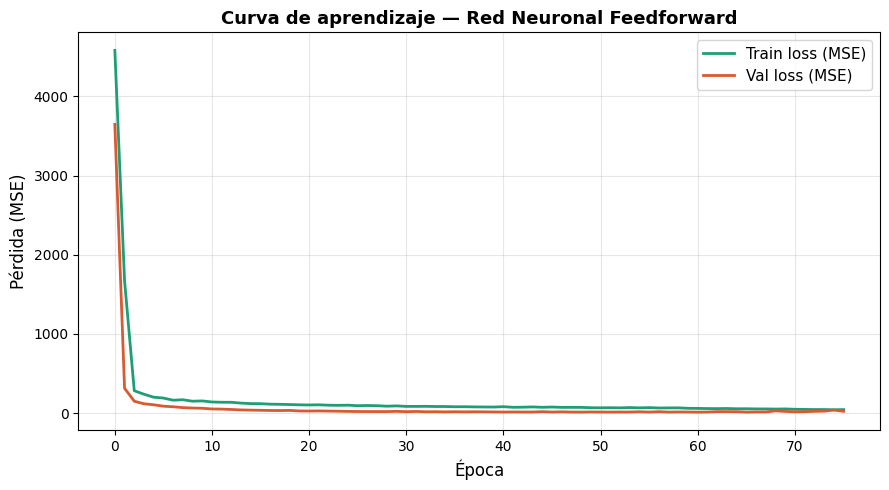

 Curva de aprendizaje guardada.


In [12]:
# ─────────────────────────────────────────────
# Curva de aprendizaje de la red neuronal
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history.history['loss'], label='Train loss (MSE)', color='#1D9E75', linewidth=2)
ax.plot(history.history['val_loss'], label='Val loss (MSE)', color='#D85A30', linewidth=2)
ax.set_xlabel('Época', fontsize=12)
ax.set_ylabel('Pérdida (MSE)', fontsize=12)
ax.set_title('Curva de aprendizaje — Red Neuronal Feedforward',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('curva_aprendizaje_nn.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Curva de aprendizaje guardada.")

**TABLA COMPARATIVA DE METRICAS**

In [13]:
# ─────────────────────────────────────────────
# Tabla comparativa de los 5 modelos
# ─────────────────────────────────────────────
tabla = pd.DataFrame(resultados).T
tabla = tabla[['R2', 'RMSE', 'MAE', 'Tiempo (s)']]
tabla = tabla.round(4)

# Identificar el mejor modelo (mayor R²)
mejor_modelo = tabla['R2'].idxmax()
tabla['Mejor'] = ['★' if idx == mejor_modelo else '' for idx in tabla.index]

print("=" * 65)
print("TABLA COMPARATIVA DE MÉTRICAS — 5 MODELOS (conjunto de prueba)")
print("=" * 65)
print(tabla.to_string())
print("=" * 65)
print(f"\n MEJOR MODELO: {mejor_modelo}")
print(f"   R²   = {tabla.loc[mejor_modelo, 'R2']:.4f}")
print(f"   RMSE = {tabla.loc[mejor_modelo, 'RMSE']:.4f} años")
print(f"   MAE  = {tabla.loc[mejor_modelo, 'MAE']:.4f} años")

TABLA COMPARATIVA DE MÉTRICAS — 5 MODELOS (conjunto de prueba)
                             R2    RMSE     MAE  Tiempo (s) Mejor
1. Regresión Lineal      0.8017  4.2150  3.0387      0.0296      
2. Regresión Polinomial  0.0117  9.4107  2.6122      0.0564      
3. Árbol de Decisión     0.9290  2.5223  1.7330      0.0426      
4. Random Forest         0.9546  2.0168  1.2649      4.4027     ★
5. Red Neuronal          0.8518  3.6442  2.6472     23.0559      

 MEJOR MODELO: 4. Random Forest
   R²   = 0.9546
   RMSE = 2.0168 años
   MAE  = 1.2649 años


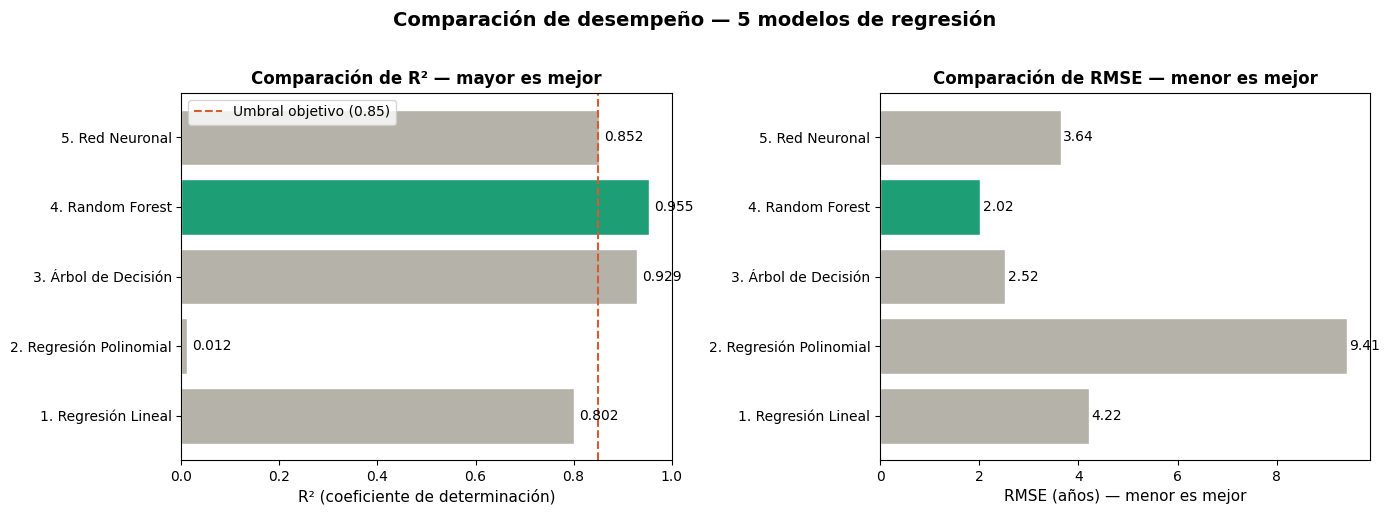

 Gráfico comparativo guardado.


In [14]:
# ─────────────────────────────────────────────
# Gráfico comparativo de R² por modelo
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modelos_nombres = list(resultados.keys())
r2_vals   = [resultados[m]['R2'] for m in modelos_nombres]
rmse_vals = [resultados[m]['RMSE'] for m in modelos_nombres]

colores_barras = ['#1D9E75' if m == mejor_modelo else '#B4B2A9' for m in modelos_nombres]

# R² (más alto = mejor)
bars1 = axes[0].barh(modelos_nombres, r2_vals, color=colores_barras, edgecolor='white')
axes[0].set_xlabel('R² (coeficiente de determinación)', fontsize=11)
axes[0].set_title('Comparación de R² — mayor es mejor', fontsize=12, fontweight='bold')
axes[0].axvline(0.85, color='#D85A30', linestyle='--', linewidth=1.5, label='Umbral objetivo (0.85)')
axes[0].legend(fontsize=10)
axes[0].set_xlim(0, 1)
for bar, val in zip(bars1, r2_vals):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=10)

# RMSE (más bajo = mejor)
bars2 = axes[1].barh(modelos_nombres, rmse_vals, color=colores_barras, edgecolor='white')
axes[1].set_xlabel('RMSE (años) — menor es mejor', fontsize=11)
axes[1].set_title('Comparación de RMSE — menor es mejor', fontsize=12, fontweight='bold')
for bar, val in zip(bars2, rmse_vals):
    axes[1].text(val + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=10)

fig.suptitle('Comparación de desempeño — 5 modelos de regresión',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Gráfico comparativo guardado.")

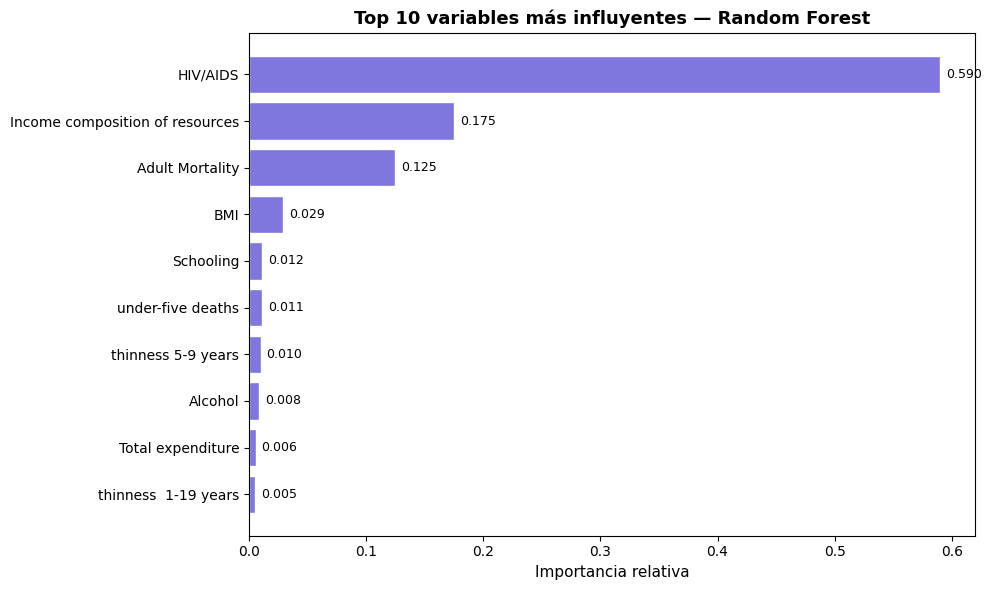

 Importancia de variables guardada.

Top 5 predictores:
HIV/AIDS                           0.590089
Income composition of resources    0.174871
Adult Mortality                    0.124779
BMI                                0.029470
Schooling                          0.011528


In [15]:
# ─────────────────────────────────────────────
# Importancia de variables (mejor modelo si es RF)
# ─────────────────────────────────────────────
if 'Random Forest' in mejor_modelo:
    importancias = pd.Series(m4.feature_importances_, index=FEATURE_NAMES)
    importancias = importancias.sort_values(ascending=True).tail(10)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(importancias.index, importancias.values, color='#7F77DD', edgecolor='white')
    ax.set_xlabel('Importancia relativa', fontsize=11)
    ax.set_title('Top 10 variables más influyentes — Random Forest',
                 fontsize=13, fontweight='bold')
    for i, (name, val) in enumerate(importancias.items()):
        ax.text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('importancia_variables.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(" Importancia de variables guardada.")
    print("\nTop 5 predictores:")
    print(importancias.sort_values(ascending=False).head(5).to_string())

In [19]:
# ─────────────────────────────────────────────
# Exportar mejor modelo + scaler para el dashboard
# ─────────────────────────────────────────────
# Estos archivos se usarán en el dashboard Streamlit

# Guardar el mejor modelo (asumiendo Random Forest)
joblib.dump(m4, 'mejor_modelo_rf.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

# Guardar también los nombres de features y rangos para los sliders
metadata = {
    'features': FEATURE_NAMES,
    'feature_min': X.min().to_dict(),
    'feature_max': X.max().to_dict(),
    'feature_median': X.median().to_dict(),
    'target': TARGET,
    'modelo': 'Random Forest Regressor'
}
joblib.dump(metadata, 'metadata.pkl')

['metadata.pkl']